In [1]:

!pip install -q nltk spacy scikit-learn seaborn


!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import nltk
import pandas as pd
import numpy as np
import spacy

from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK datasets
nltk.download('movie_reviews')
nltk.download('stopwords')

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

print("✅ Setup Complete")

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✅ Setup Complete


In [3]:
documents = [
    (' '.join(movie_reviews.words(fileid)), category)
    for category in movie_reviews.categories()
    for fileid in movie_reviews.fileids(category)
]

df = pd.DataFrame(documents, columns=['text', 'label'])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 2)


,text,label
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard ' s quick movie review damn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' first...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


In [4]:
def preprocess(text):
    doc = nlp(text.lower())

    tokens = [
        token.lemma_ for token in doc
        if token.is_alpha and token.text not in stop_words
    ]

    tokens = [stemmer.stem(word) for word in tokens]

    return " ".join(tokens)

# Use subset (faster)
df_subset = df.sample(500, random_state=42)

df_subset['cleaned_text'] = df_subset['text'].apply(preprocess)

print("✅ Preprocessing Done")
df_subset[['text','cleaned_text']].head()

✅ Preprocessing Done


,text,cleaned_text
1860,the verdict : spine - chilling drama from horr...,verdict spine chill drama horror maestro steph...
353,""" the 44 caliber killer has struck again . "" s...",calib killer strike star john leguizamo mira s...
1333,in the company of men made a splash at the sun...,compani man make splash sundanc film festiv ye...
905,"in the year 2029 , captain leo davidson ( mark...",year captain leo davidson mark wahlberg boogi ...
1289,[ note that followups are directed to rec . ar...,note followup direct rec art movi current film...


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df_subset['cleaned_text'],
    df_subset['label'],
    test_size=0.2,
    random_state=42
)

# Count Vectorizer
count_vec = CountVectorizer()
X_train_count = count_vec.fit_transform(X_train)

# TF-IDF Vectorizer
tfidf_vec = TfidfVectorizer()
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

print("✅ Vectorization Done")

✅ Vectorization Done


In [6]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("✅ Model Trained")


✅ Model Trained


In [7]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.77

Classification Report:

              precision    recall  f1-score   support

         neg       0.70      0.96      0.81        52
         pos       0.93      0.56      0.70        48

    accuracy                           0.77       100
   macro avg       0.82      0.76      0.76       100
weighted avg       0.81      0.77      0.76       100



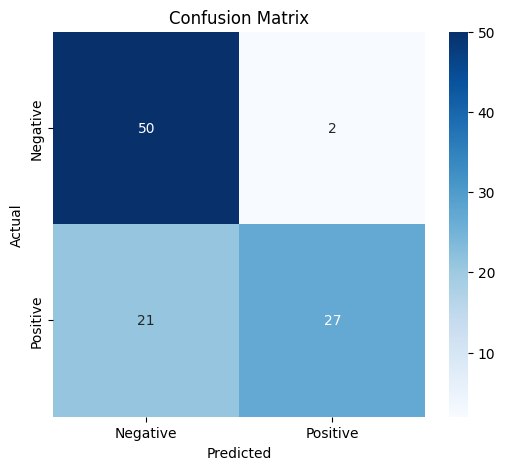

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
def predict_review(text):
    cleaned = preprocess(text)
    vector = tfidf_vec.transform([cleaned])

    prediction = model.predict(vector)[0]
    prob = model.predict_proba(vector).max()

    print("\nReview:", text)
    print("Prediction:", prediction.upper())
    print("Confidence:", round(prob*100,2), "%")

# Test
predict_review("This movie was absolutely amazing!")
predict_review("Worst movie ever, boring and waste of time.")


Review: This movie was absolutely amazing!
Prediction: NEG
Confidence: 51.78 %

Review: Worst movie ever, boring and waste of time.
Prediction: NEG
Confidence: 76.32 %
